In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("Social_Network_Ads.csv")
df=df.iloc[:,1:]

In [3]:
df["Male"]=df["Gender"].apply(lambda x:1 if x=="Male" else 0)
df["Female"]=df["Gender"].apply(lambda x:1 if x=="Female" else 0)

In [4]:
df=df.drop("Gender",axis=1)


In [5]:
df.rename(columns={"EstimatedSalary":"Est_sal"})

,Age,Est_sal,Purchased,Male,Female
0,19,19000,0,1,0
1,35,20000,0,1,0
2,26,43000,0,0,1
3,27,57000,0,0,1
4,19,76000,0,1,0
...,...,...,...,...,...
395,46,41000,1,0,1
396,51,23000,1,1,0
397,50,20000,1,0,1
398,36,33000,0,1,0


In [6]:
from sklearn.model_selection import train_test_split
y=df["Purchased"]
x=df.drop("Purchased",axis=1)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [7]:
x_train

,Age,EstimatedSalary,Male,Female
336,58,144000,1,0
64,59,83000,0,1
55,24,55000,0,1
106,26,35000,0,1
300,58,38000,0,1
...,...,...,...,...
323,48,30000,0,1
192,29,43000,1,0
117,36,52000,1,0
47,27,54000,0,1


In [8]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
scaler.fit(x_train)

# 
x_train_scaler=scaler.transform(x_train)
x_test_scaler=scaler.transform(x_test)

In [9]:
x_train

,Age,EstimatedSalary,Male,Female
336,58,144000,1,0
64,59,83000,0,1
55,24,55000,0,1
106,26,35000,0,1
300,58,38000,0,1
...,...,...,...,...
323,48,30000,0,1
192,29,43000,1,0
117,36,52000,1,0
47,27,54000,0,1


In [11]:
x_train_scaler=pd.DataFrame(x_train_scaler,columns=x_train.columns)
x_train_scaler.head(3)

,Age,EstimatedSalary,Male,Female
0,1.922950,2.146016,1.025320,-1.025320
1,2.020161,0.378719,-0.975305,0.975305
2,-1.382215,-0.432499,-0.975305,0.975305


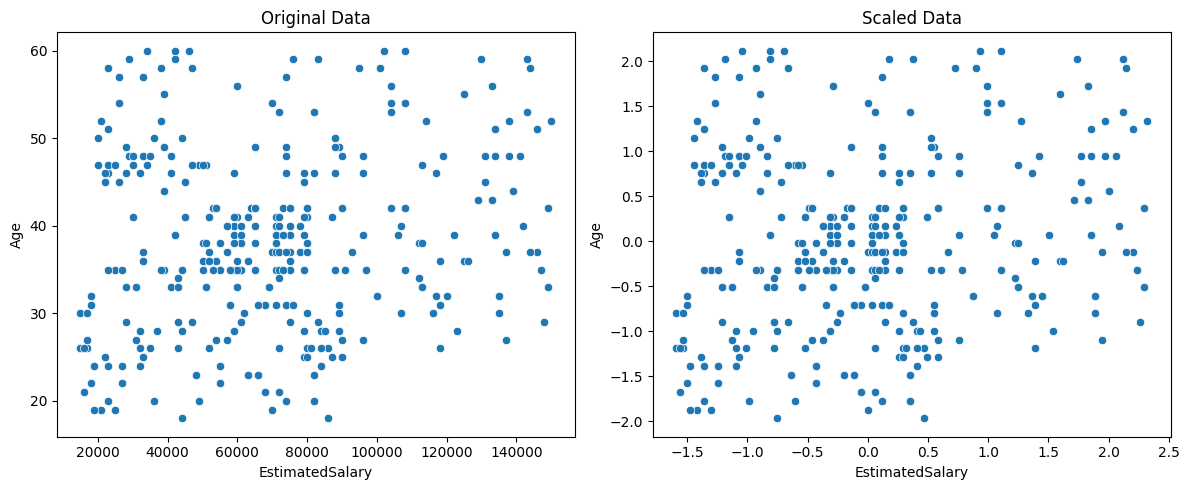

In [18]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

sns.scatterplot(
    data=x_train,
    x="EstimatedSalary",
    y="Age",
    ax=ax1
)

sns.scatterplot(
    data=x_train_scaler,
    x="EstimatedSalary",
    y="Age",
    ax=ax2
)

ax1.set_title("Original Data")
ax2.set_title("Scaled Data")

plt.tight_layout()
plt.show()